In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation


import scipy
import numpy as np
import pandas as pd
import datetime as dt

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans
import scipy.signal as signal
import scipy.special as special

In [2]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

import bout.clustering as clstr
import bout.assembly as bt

In [3]:
from models.bat_call_detector.model_detector import BatCallDetector

In [4]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

In [5]:
C = 343 # m/s speed of sound in air
FS = 250000
SNR_CALC_LENGTH = 0.030
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SELECTED_CHANNEL_FOR_REF = 6
NUM_CHANNELS_TOTAL = 8
FILE_DURATION = 600
HOUR_TAG = 'hour_0'
ZMAG_REF_TO_6 = 29.125
ZMAG_REF_TO_7 = 31.6875
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
A_LOCS_MAT = np.array([[-XMAG_REF_TO_1, -YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [0, 0, ZMAG_REF_TO_7],
                    [0, 0, 0]])

In [6]:
import UBNA_localize_process_GCC__20250428 as localize

In [31]:
%matplotlib inline

microphones_used = np.array([1, 2, 3, 4, 6, 7])
ind_of_selected_channel = np.where(microphones_used==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = microphones_used[ind_of_selected_channel]
non_ref_microphones_used = microphones_used[microphones_used!=SELECTED_MIC_FOR_REF]
num_good_channels = microphones_used.shape[0]
num_nonref_channels = num_good_channels-1

In [24]:
file_dir = Path('/Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250424/inUBNA/array')
site_key = 'Carp'
freq_key = ''

data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = dict()
file_paths["SITE_folder"] = f'/Users/adityakrishna/duty-cycle-investigation/data/2022_detector_summaries/{data_params["site_tag"]}'
file_paths["detector_TYPE_SITE_YEAR"] = f'{data_params["detector_tag"]}__{data_params["type_tag"]}{data_params["site_tag"]}_2022_{data_params["assembly_type"]}'
location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0, low_memory=False)
bout_params = bt.get_bout_params_from_location(location_df, data_params)
bout_params

{'site_key': 'Carp', 'LF_bci': 3904.554260760447, 'HF_bci': 5203.014061749601}

In [32]:
start_stop_file = (file_dir / 'Start_Stop_Times.txt')
with open(start_stop_file, "r", encoding="utf-8") as file:
    content = file.read()
    print(content)


Start time: 03:35:14 04/25/25 UTC
Stop time: 04:48:20 04/25/25 UTC



In [33]:
start_stop_arr = content.split('\n')
start_of_session = start_stop_arr[0]
FILE_DATETIME = dt.datetime.strptime(start_of_session, 'Start time: %H:%M:%S %m/%d/%y UTC')

In [34]:
%matplotlib inline
file_offset = 600
FILE_TIME_TAG = f'{int(file_offset)}to{int(file_offset+FILE_DURATION)}'
dir_name = f'{HOUR_TAG}_{FILE_TIME_TAG}'
write_dir = file_dir / dir_name

channel_dets = localize.get_dets_observed_from_all_channels(microphones_used, file_dir, file_offset)
channel_dets = channel_dets[channel_dets['KMEANS_CLASSES']=='LF'].copy()
channel_dets.sort_values(by='start_time', inplace=True)
channel_dets.reset_index(drop=True, inplace=True)
channel_dets['freq_group'] = channel_dets['KMEANS_CLASSES']
channel_dets['call_start_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['cycle_ref_time'] = pd.to_timedelta(channel_dets['start_time']*1e9) + FILE_DATETIME
channel_dets['call_end_time'] = pd.to_timedelta(channel_dets['end_time']*1e9) + FILE_DATETIME
channel_dets['start_time_wrt_ref'] = channel_dets['start_time']
channel_dets['end_time_wrt_ref'] = channel_dets['end_time']
removed_overlaps = localize.remove_overlapping_events(channel_dets, OVERLAP_TIME_THRESHOLD=8e-3)
snr_thresh_dets = removed_overlaps[removed_overlaps['SNR']>=20].copy()

In [35]:
tagged_dets = bt.classify_bouts_in_detector_preds_for_freqgroups(snr_thresh_dets, bout_params)
bout_metrics = bt.construct_bout_metrics_from_location_df_for_freqgroups(tagged_dets)
bout_metrics

,start_time_of_bout,end_time_of_bout,start_time_wrt_ref,end_time_wrt_ref,start_time,end_time,low_freq,high_freq,freq_group,cycle_ref_time_start,cycle_ref_time_end,number_of_dets,bout_duration,bout_duration_in_secs
0,2025-04-25 03:46:33.888500000,2025-04-25 03:46:42.324000000,679.8885,688.3240,679.8885,688.3240,24609,42211,LF,2025-04-25 03:46:33.888500000,2025-04-25 03:46:42.309500000,36,0 days 00:00:08.435500,8.435500
1,2025-04-25 03:47:22.546500000,2025-04-25 03:47:28.806400000,728.5465,734.8064,728.5465,734.8064,22031,50716,LF,2025-04-25 03:47:22.546500000,2025-04-25 03:47:28.790500000,27,0 days 00:00:06.259900,6.259900
2,2025-04-25 03:47:51.509500000,2025-04-25 03:47:53.239300000,757.5095,759.2393,757.5095,759.2393,25468,31835,LF,2025-04-25 03:47:51.509500000,2025-04-25 03:47:53.224500000,7,0 days 00:00:01.729800,1.729800
3,2025-04-25 03:47:58.016500000,2025-04-25 03:48:03.491900000,764.0165,769.4919,764.0165,769.4919,24609,44060,LF,2025-04-25 03:47:58.016500000,2025-04-25 03:48:03.477500000,8,0 days 00:00:05.475400,5.475400
4,2025-04-25 03:48:19.716500000,2025-04-25 03:48:56.100900000,785.7165,822.1009,785.7165,822.1009,21171,49900,LF,2025-04-25 03:48:19.716500000,2025-04-25 03:48:56.079500000,171,0 days 00:00:36.384400,36.384400
5,2025-04-25 03:49:03.466500000,2025-04-25 03:49:48.195700000,829.4665,874.1957,829.4665,874.1957,21171,47867,LF,2025-04-25 03:49:03.466500000,2025-04-25 03:49:48.182500000,146,0 days 00:00:44.729200,44.729200
6,2025-04-25 03:49:57.238499999,2025-04-25 03:50:08.078500000,883.2385,894.0785,883.2385,894.0785,21171,48255,LF,2025-04-25 03:49:57.238499999,2025-04-25 03:50:08.061500000,66,0 days 00:00:10.840000001,10.840000
7,2025-04-25 03:50:12.061500000,2025-04-25 03:51:18.468800000,898.0615,964.4688,898.0615,964.4688,21171,49816,LF,2025-04-25 03:50:12.061500000,2025-04-25 03:51:18.449500000,282,0 days 00:01:06.407300,66.407300
8,2025-04-25 03:51:22.984500000,2025-04-25 03:51:33.150200000,968.9845,979.1502,968.9845,979.1502,22031,50024,LF,2025-04-25 03:51:22.984500000,2025-04-25 03:51:33.130500000,52,0 days 00:00:10.165700,10.165700
9,2025-04-25 03:51:38.965500000,2025-04-25 03:52:00.807800000,984.9655,1006.8078,984.9655,1006.8078,22890,50542,LF,2025-04-25 03:51:38.965500000,2025-04-25 03:52:00.796499999,114,0 days 00:00:21.842300,21.842300


In [36]:
def plot_three_plane_trajectories(ax1, ax2, ax3, dets, good_bucket, bucket, mic_locs, start, length):
    cmap = plt.get_cmap('viridis')
    map_vals = (dets['SNR'])
    # color_vals = np.linspace(start, start+length, bucket.shape[1])
    norm = plt.Normalize(map_vals.min(), map_vals.max())
    line_colors = cmap(norm(map_vals))
    ax1.plot(good_bucket[0,:], good_bucket[1,:], alpha=0.4, color='k')
    ax1.scatter(bucket[0,:], bucket[1,:], color=line_colors, alpha=1, s=50)
    ax1.scatter(x=mic_locs[:,0], y=mic_locs[:,1], facecolor='yellow', edgecolor='k')
    ax1.scatter(x=0, y=0, facecolor='yellow', edgecolor='k')

    ax2.plot(good_bucket[1,:], good_bucket[2,:], alpha=0.4, color='k')
    ax2.scatter(bucket[1,:], bucket[2,:], color=line_colors, alpha=1, s=50)
    ax2.scatter(x=mic_locs[:,1], y=mic_locs[:,2], facecolor='yellow', edgecolor='k')
    ax2.scatter(x=0, y=0, facecolor='yellow', edgecolor='k')

    ax3.plot(good_bucket[0,:], good_bucket[2,:], alpha=0.4, color='k')
    ax3.scatter(bucket[0,:], bucket[2,:], color=line_colors, alpha=1, s=50)
    ax3.scatter(x=mic_locs[:,0], y=mic_locs[:,2], facecolor='yellow', edgecolor='k')
    ax3.scatter(x=0, y=0, facecolor='yellow', edgecolor='k')


Currently at /Volumes/Elements/UBNA_array_tests2025/mic_array_test_20250424/inUBNA/array/hour_0_600to1200/hour_0_channel6_600to1200.WAV


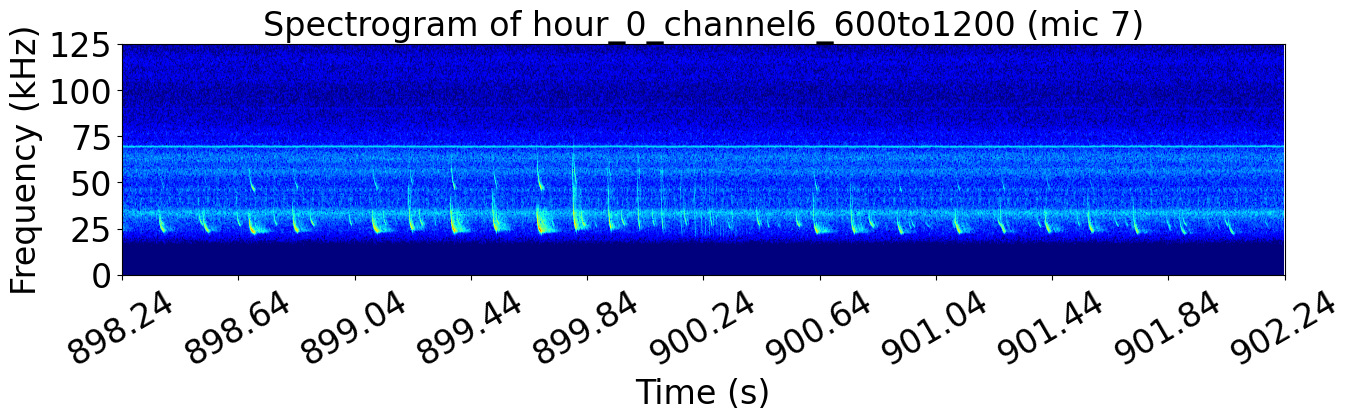

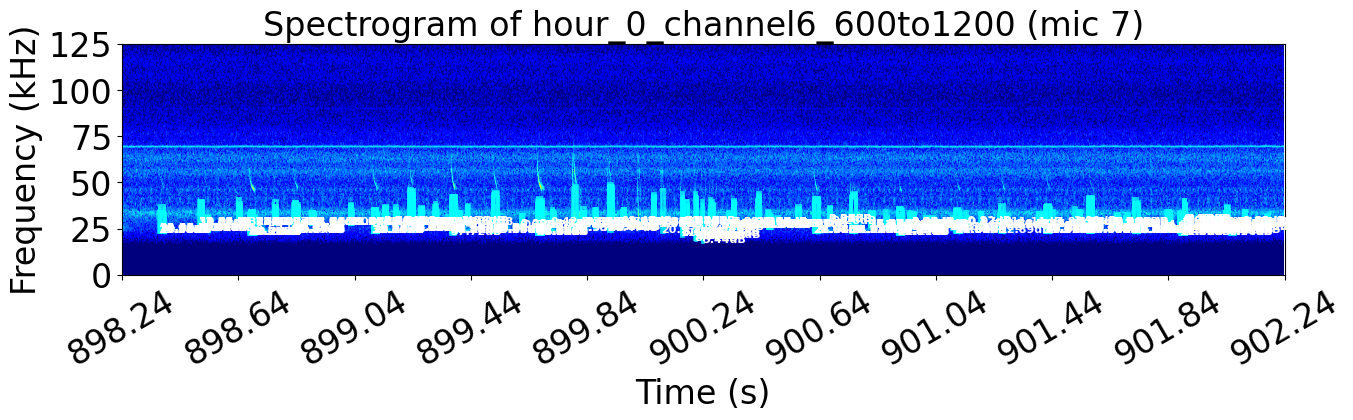

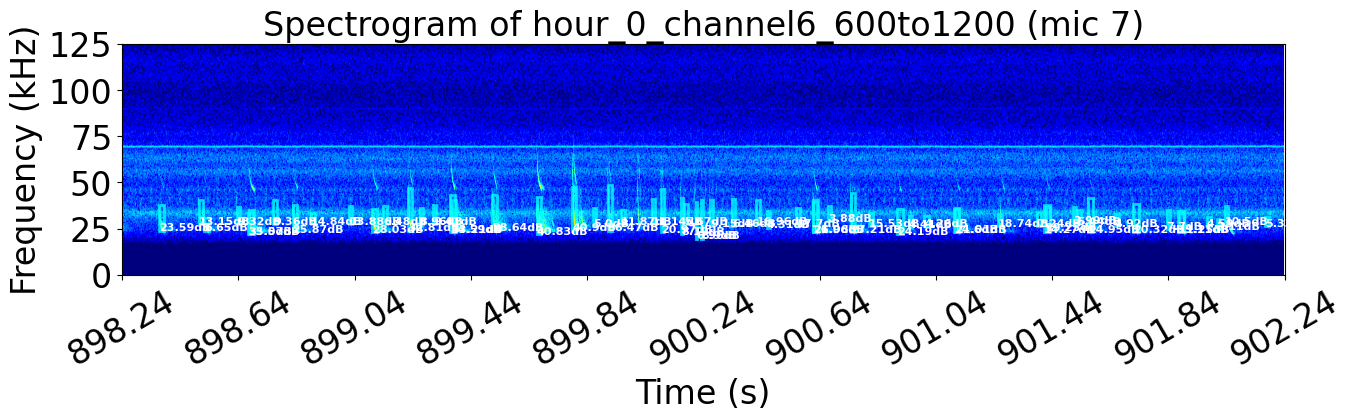

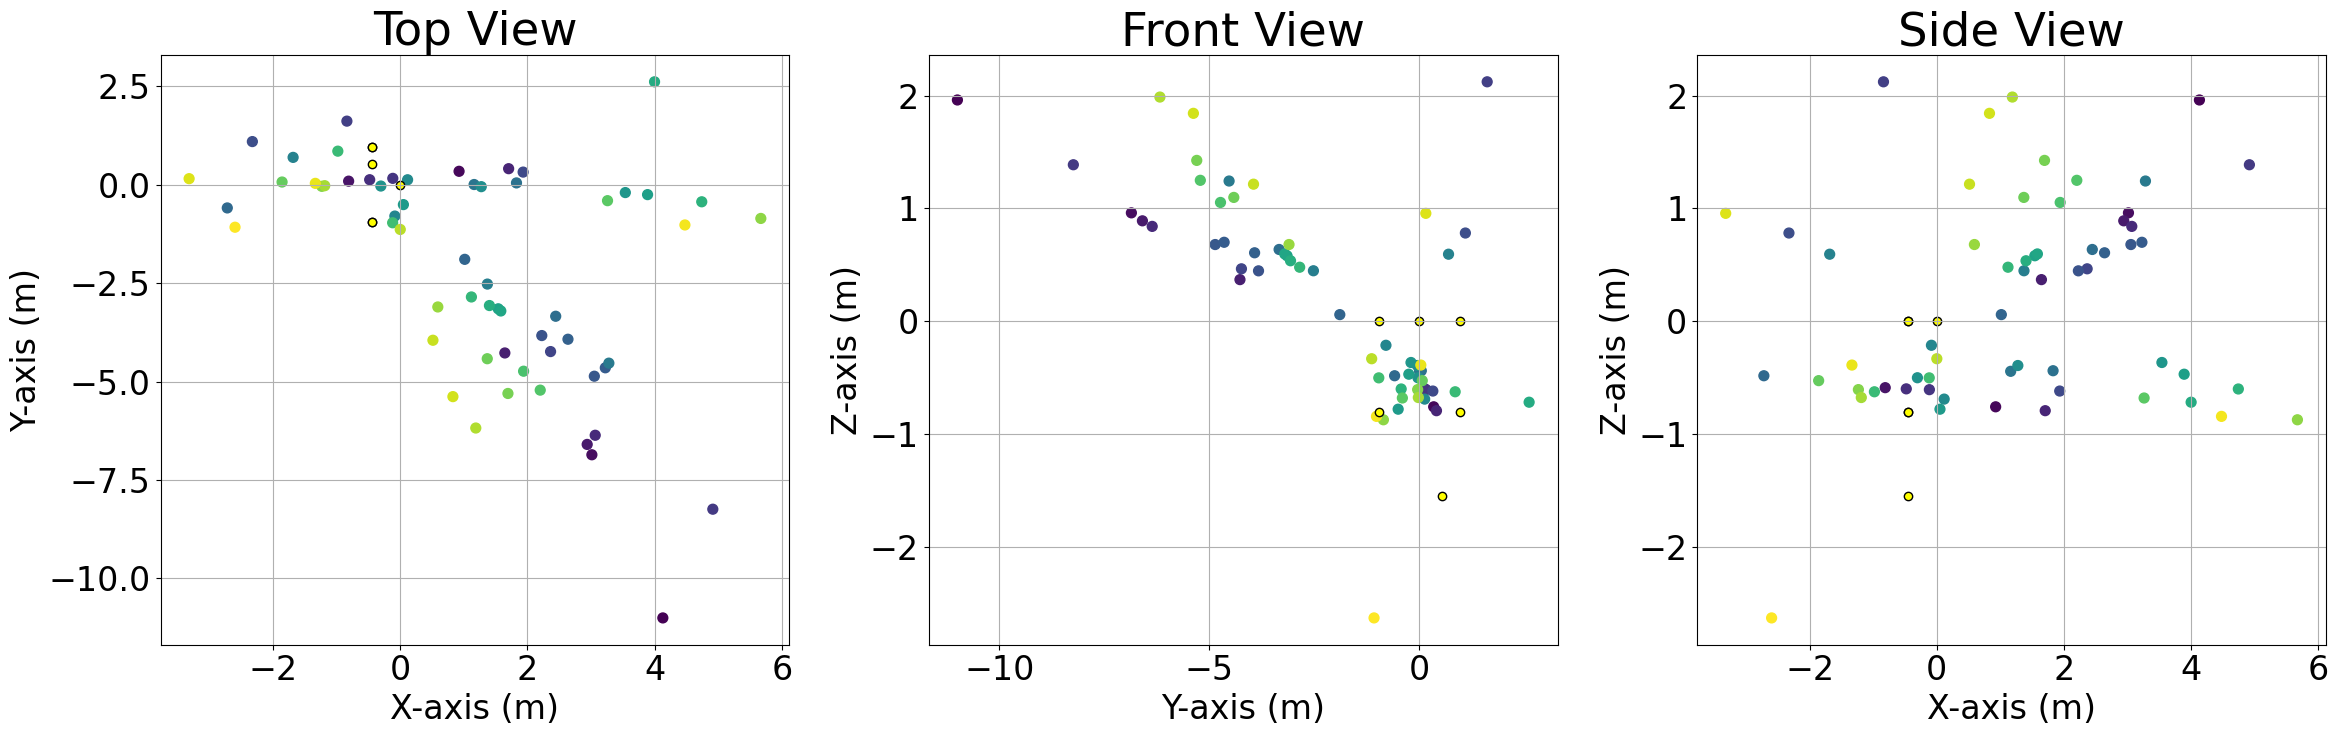

In [44]:
write_file = write_dir / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

bout = bout_metrics.iloc[6]
start = bout['start_time'] - file_offset+15
length = 4
plot_channel_dets = channel_dets.loc[(channel_dets['start_time']>=(file_offset+start))&(channel_dets['end_time']<=(file_offset+start+length))]
plot_dets = removed_overlaps.loc[(removed_overlaps['start_time']>=(file_offset+start))&(removed_overlaps['end_time']<=(file_offset+start+length))]

set_for_tdoa = plot_dets[plot_dets['SNR']>=3].reset_index(drop=True).copy()
localize.plot_audio_bout(write_file, SELECTED_CHANNEL_FOR_REF, start, length, file_offset, plot_channel_dets, set_for_tdoa)

calls_for_tdoa, call_voltage_rms, snr_facs_for_tdoa, det_durs_for_tdoa = localize.find_relevant_tdoa_arrays(set_for_tdoa, microphones_used, file_offset, write_dir)
t_delay_wrt_selected_channel = localize.find_d_mics_to_ref_using_GCC(set_for_tdoa, microphones_used, calls_for_tdoa, snr_facs_for_tdoa, det_durs_for_tdoa)
d_mics_to_ref_meters, A_locs_mat_tdoa_inches = localize.get_d_mics_with_mic_locs(microphones_used, t_delay_wrt_selected_channel, SELECTED_CHANNEL_FOR_REF)
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_inches * (254/10000)

source_points = localize.assemble_source_points_in_meters(d_mics_to_ref_meters, microphones_used, A_locs_mat_tdoa_meters)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
plt.rcParams.update({'font.size':28})
localize.plot_three_plane_trajectories(ax1, ax2, ax3, set_for_tdoa, np.zeros(source_points.shape), source_points, A_locs_mat_tdoa_meters, start, length)
ax1.set_title('Top View')
ax1.grid(which='both')
ax1.set_xlabel('X-axis (m)')
ax1.set_ylabel('Y-axis (m)')

ax2.set_title('Front View')
ax2.grid(which='both')
ax2.set_xlabel('Y-axis (m)')
ax2.set_ylabel('Z-axis (m)')

ax3.set_title('Side View')
ax3.grid(which='both')
ax3.set_xlabel('X-axis (m)')
ax3.set_ylabel('Z-axis (m)')

plt.tight_layout()
plt.show()